<a href="https://colab.research.google.com/github/gustavox0/Tecnicas-Avanzdas-ML/blob/main/M7_AI2_SalazarGustavo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Contexto**

En la actualidad, disponemos de framework de Deep Learning, como Tensorflow o Pytorch, que facilitan mucho el desarrollo de Redes Neuronales porque ofrecen:

  - Componentes básicos para desarrollar nuestros propios modelos.
  - Distintos modelos de Deep Learning pre-entrenados.
  - Datasets para entrenar esos modelos.

En esta actividad adquiriremos un conocimiento básico de ambos framework mediante un ejercicio práctico que consiste en:

  - Cargar el dataset de imágenes CIFAR10 (del Canadian Institute for Advanced Research), disponible en ambos framework. Este dataset presenta las siguientes características:
    - Consta de 50.000 imágenes de entrenamiento y 10.000 de prueba.
    - Los datasets se reparten en 10 clases:
      * 'plane' (avión)
      * 'car' (coche)
      * 'bird' (pájaro)
      * 'cat' (gato)
      * 'deer' (ciervo)
      * 'dog' (perro)
      * 'frog' (rana)
      * 'horse' (caballo)
      * 'ship' (barco)
      * 'truck' (camión)

    - Las imágenes tienen una dimensión de 32 x 32 pixels, y son en color (3 canales).
  - Crear una Red Neuronal simple (feedforward) con el modo Sequential de ambos framework, compuesta por:
    - Una capa para pasar las imágenes de 2D a 1D (si es necesario).
    - Dos capas lineales con 256 y 128 nodos, seguidas cada una de una función de activación ReLU.
    - Una capa de salida softmax que obtenga la probabilidad de cada clase (si fuese necesario).
  - Entrenar ambas Redes con las opciones siguientes:
    - Optimizador: Stochastic Gradient Descent.
    - Función de pérdida (loss): cross entropy, teniendo en cuenta que nuestra salida es categórica.
    - Tamaño de lote (batch size): 16 imágenes o Entrenar durante 100 iteraciones (epochs) o Proporción entre entrenamiento y validación: 80% - 20%.
  - Evaluación de ambos modelos:
    - Grafica las curvas de loss para datos de entrenamiento y validación en función de la iteración.
    - Se requiere mostrar el accuracy final del modelo una vez se evalúa con la partición de test. Del mismo modo, mostrar el accuracy en la partición de validación.

**Consideraciones:**

  - Framework a utilizar: Tensorflow y Pytorch.
  - Conviene revisar que las dimensiones de la Red son correctas antes de comenzar a entrenar.
  - Al entrenar con tensorflow, utilizar los métodos compile y fit heredados.

Adicionalmente al código y la experimentación, debéis contestar obligatoriamente a las siguientes preguntas:

  - ¿Qué framework ofrece una mayor flexibilidad?
  - ¿cuál de los dos facilita más la depuración en caso de que haya errores en la definición del modelo?
  - Considerando que hemos utilizado el mismo dataset que en la práctica anterior, ¿Qué modelo ha obtenido mejores resultados, SVM o la red feedforward? ¿por qué?
  - ¿Qué ocurre si usamos la función de loss CrossEntropyLoss en torch y la última capa de la red tiene una activación softmax o log_softmax?

#Solución

Para dar respuesta a esta actividad, voy a proceder con el desarrollo de las siguientes secciones:

  1. Cargar el dataset
  2. Crear la Red Neuronal Simple con dos frameworks
    - Tensorflow
    - Pytorch
  3. Entrenar redes
  4. Evaluación de los modelos
  5. Consideraciones adicionales

Antes de iniciar con cada uno de los apartados, cargo los paquetes necesarios.

In [43]:
#paquete pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score

#paquete tensorflow
import tensorflow as tf
import tensorflow_datasets as tfds
import random, os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import SparseCategoricalCrossentropy

#paquetes generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Cargar el dataset

### Tensorflow

A continuación cargamos el dataset con Tensorflow

In [44]:
# Descargar CIFAR-10
(x_train_tf, y_train_tf), (x_test_tf, y_test_tf) = tf.keras.datasets.cifar10.load_data()

print("Tamaño del set de entrenamiento:", x_train_tf.shape)
print("Tamaño del set de prueba:", x_test_tf.shape)
print("Tamaño del vector de etiquetas entrenamiento:", y_train_tf.shape)
print("Tamaño del vector de etiquetas prueba:", y_test_tf.shape)

Tamaño del set de entrenamiento: (50000, 32, 32, 3)
Tamaño del set de prueba: (10000, 32, 32, 3)
Tamaño del vector de etiquetas entrenamiento: (50000, 1)
Tamaño del vector de etiquetas prueba: (10000, 1)


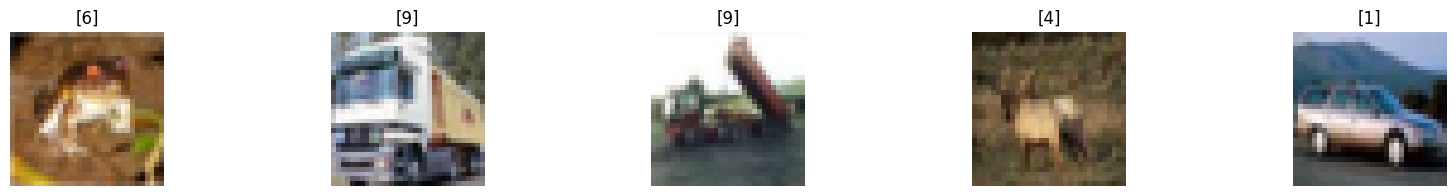

In [45]:
# Mostrar 5 primeras imágenes de entrenamiento
fig, axes = plt.subplots(1, 5, figsize=(20, 2))
for i in range(5):
    axes[i].imshow(x_train_tf[i], cmap='gray')
    axes[i].set_title(y_train_tf[i])
    axes[i].axis('off') # Hide axes ticks
plt.show()


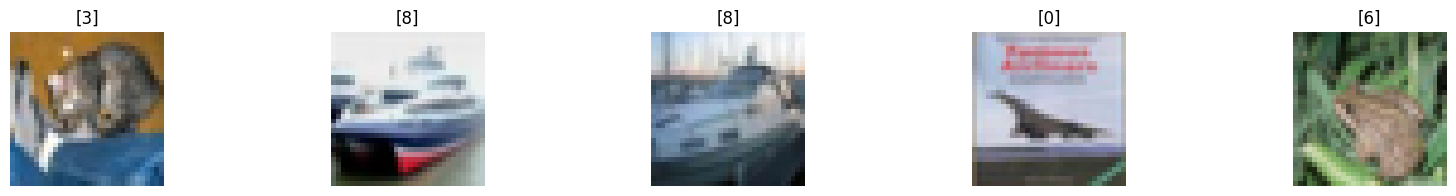

In [46]:
# Mostrar 5 primeras imágenes de prueba
fig, axes = plt.subplots(1, 5, figsize=(20, 2))
for i in range(5):
    axes[i].imshow(x_test_tf[i], cmap='gray')
    axes[i].set_title(y_test_tf[i])
    axes[i].axis('off') # Hide axes ticks
plt.show()

In [47]:
#Información general de los datasets
cifar10_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print("Nombe de las clases:", cifar10_class_names)
print("Nº de clases:", len(cifar10_class_names))
print("Nº instancias (train set):", x_train_tf.shape[0])
print("Nº instancias (test set):", x_test_tf.shape[0])
# Nº instancias por clase
unique_classes_train, counts_train = np.unique(y_train_tf, return_counts=True)
print("Nº instancias por clase (train set):")
for i in range(len(unique_classes_train)):
    print(f"\tClase '{cifar10_class_names[unique_classes_train[i]]}': {counts_train[i]}")

unique_classes_test, counts_test = np.unique(y_test_tf, return_counts=True)
print("Nº instancias por clase (test set):")
for i in range(len(unique_classes_test)):
    print(f"\tClase '{cifar10_class_names[unique_classes_test[i]]}': {counts_test[i]}")

Nombe de las clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Nº de clases: 10
Nº instancias (train set): 50000
Nº instancias (test set): 10000
Nº instancias por clase (train set):
	Clase 'airplane': 5000
	Clase 'automobile': 5000
	Clase 'bird': 5000
	Clase 'cat': 5000
	Clase 'deer': 5000
	Clase 'dog': 5000
	Clase 'frog': 5000
	Clase 'horse': 5000
	Clase 'ship': 5000
	Clase 'truck': 5000
Nº instancias por clase (test set):
	Clase 'airplane': 1000
	Clase 'automobile': 1000
	Clase 'bird': 1000
	Clase 'cat': 1000
	Clase 'deer': 1000
	Clase 'dog': 1000
	Clase 'frog': 1000
	Clase 'horse': 1000
	Clase 'ship': 1000
	Clase 'truck': 1000


### Pytorch

In [48]:
# cargar dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
py_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
py_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

print(f"Entrenamiento: {len(py_train)} ejemplos")
print(f"Prueba: {len(py_test)} ejemplos")

Entrenamiento: 50000 ejemplos
Prueba: 10000 ejemplos


In [49]:
# Mostrar información de dimensiones
print("\nInformación de dimensiones:")
print(f"X_train_py shape: {len(py_train)} ejemplos")
print(f"y_train_py shape: {len(py_train)} etiquetas")
print(f"X_test_py shape: {len(py_test)} ejemplos")
print(f"y_test_py shape: {len(py_test)} etiquetas")


Información de dimensiones:
X_train_py shape: 50000 ejemplos
y_train_py shape: 50000 etiquetas
X_test_py shape: 10000 ejemplos
y_test_py shape: 10000 etiquetas


Mostrar 5 primeras imágenes

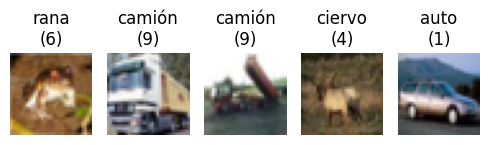

In [50]:
# Nombres de las clases (en orden)
classes = ('avión', 'auto', 'pájaro', 'gato', 'ciervo',
           'perro', 'rana', 'caballo', 'barco', 'camión')

# Función para mostrar imágenes
def imshow(img):
    img = img.numpy()  # Convertir tensor a numpy
    img = np.transpose(img, (1, 2, 0))  # (C, H, W) → (H, W, C)
    img = (img + 1) / 2  # Reescalar de [-1,1] a [0,1]
    plt.imshow(img)
    plt.axis('off')

# Crear figura para mostrar las imágenes
plt.figure(figsize=(5, 2))

# Mostrar las 5 primeras imágenes
for i in range(5):
    image, label = py_train[i]  # Obtener imagen y etiqueta

    # Mostrar imagen
    plt.subplot(1, 5, i+1)
    imshow(image)
    plt.title(f'{classes[label]}\n({label})')

plt.tight_layout()
plt.show()

In [51]:
# Información adicional
print("\nInformación de las imágenes:")
print(f"- Número total de imágenes de entrenamiento: {len(py_train)}")
print(f"- Número total de imágenes de prueba: {len(py_test)}")
print(f"- Forma de cada imagen: {py_train[0][0].shape} (Canales, Alto, Ancho)")
print(f"- Rango de valores de píxeles: [{py_train[0][0].min():.2f}, {py_train[0][0].max():.2f}]")
print(f"- Nombres de cada clase: {py_train.classes}")


Información de las imágenes:
- Número total de imágenes de entrenamiento: 50000
- Número total de imágenes de prueba: 10000
- Forma de cada imagen: torch.Size([3, 32, 32]) (Canales, Alto, Ancho)
- Rango de valores de píxeles: [-1.00, 1.00]
- Nombres de cada clase: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Como puede observarse, a diferencia de tensorflow, Pytorch carga los datos con una estructura  de lista de tuplas. Es decir, cada elemento es de la forma (imagen, etiqueta). Por tanto, el dataset py_train contiene tanto las imagenes como su etiqueta para el conjunto de prueba y el dataset py_test contiene tanto las imágenes como su etiqueta para el conjunto de prueba.

## Crear la Red Neuronal Simple

### Tensorflow

In [52]:
#Para replicabilidad
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
set_seed(42)

In [53]:
# Definir el modelo
modelo_tf = Sequential([
    Input(shape=(32, 32, 3)),
    Flatten(),  #pasar 2D a 1D (es decir, a vector para que lo acepte Dense)
    Dense(256, activation='relu'), # Primera capa oculta (256 neuronas) + ReLU
    Dense(128, activation='relu'),# Segunda capa oculta (128 neuronas) + ReLU
    Dense(10, activation='softmax')# Capa de salida (10 neuronas para 10 clases) + Softmax para transformar salida a probabilidades
])

# Preparar el modelo para entrenamiento
modelo_tf.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),  # Stochastic Gradient Descent con la que vamos a entrenar el modelo
    loss='sparse_categorical_crossentropy',  # etiquetas enteras
    metrics=['accuracy']  # Métrica de evaluación
)

### Pytorch

In [54]:
#definir el modelo
modelo_py = nn.Sequential(
    nn.Flatten(),   # Capa para aplanar la imagen (3, 32, 32) -> (3072,)
    nn.Linear(32*32*3, 256), #Primera capa oculta: 256 neuronas + ReLU
    nn.ReLU(),
    nn.Linear(256, 128), # Segunda capa oculta: 128 neuronas + ReLU
    nn.ReLU(),
    nn.Linear(128, 10)  # Capa de salida: 10 neuronas (sin activación, ya se activa en CrossEntropyLoss)
)
#-----------------Preparacion del modelo--------------------
# Configurar dispositivo (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo_py = modelo_py.to(device)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(modelo_py.parameters(), lr=0.001) #tasa de aprendizaje de 0,001

## Entrenar Redes

### Tensorflow

In [55]:
from sklearn.model_selection import train_test_split
set_seed(42)

#normalizar datos
x_train_tf = x_train_tf.astype('float32') / 255.0
x_test_tf = x_test_tf.astype('float32') / 255.0

# Dividir el conjunto de entrenamiento en 80% train y 20% validación
x_train_tf, x_val_tf, y_train_tf, y_val_tf = train_test_split(
    x_train_tf, y_train_tf, test_size=0.2, random_state=42
)

#Entrenar el modelo
historial=modelo_tf.fit(
    x_train_tf, y_train_tf,
    validation_data=(x_val_tf, y_val_tf),
    epochs=100,
    batch_size=16, #lotes de 16 imagenes
    shuffle=True #mezclar datos ante de cada época
)

Epoch 1/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.2183 - loss: 2.1590 - val_accuracy: 0.3160 - val_loss: 1.9412
Epoch 2/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - accuracy: 0.3355 - loss: 1.9077 - val_accuracy: 0.3517 - val_loss: 1.8486
Epoch 3/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 38s 8ms/step - accuracy: 0.3623 - loss: 1.8271 - val_accuracy: 0.3707 - val_loss: 1.7947
Epoch 4/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.3787 - loss: 1.7752 - val_accuracy: 0.3839 - val_loss: 1.7545
Epoch 5/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.3944 - loss: 1.7348 - val_accuracy: 0.3949 - val_loss: 1.7224
Epoch 6/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.4051 - loss: 1.7017 - val_accuracy: 0.4023 - val_loss: 1.6964
Epoch 7/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.4160 - loss: 1.6735 - val_accuracy: 0.4089 - val_loss: 1.6736
Epoch 8/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.4245 -

###Pytorch

In [56]:
#para replicabilidad
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True  # Operaciones deterministas (más lento)
    torch.backends.cudnn.benchmark = False     # No buscar la mejor configuración de cuDNN
    os.environ['PYTHONHASHSEED'] = str(seed)
set_seed(42)

In [57]:
# Configuraciones
batch_size = 16
num_epochs = 100
train_ratio = 0.8

# División 80/20 entre entrenamiento y validación
train_size = int(train_ratio * len(py_train))
val_size = len(py_train) - train_size
train_dataset, val_dataset = random_split(py_train, [train_size, val_size],
                                           generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(py_test, batch_size=batch_size, shuffle=False)

# Inicializar listas para graficar pérdidas por época
train_losses = []
val_losses = []

# Entrenamiento y validación
for epoch in range(num_epochs):
    modelo_py.train() #establecer modelo en modo entrenamiento
    train_loss = 0.0 #iniciar pérdida acumulada en epoca

    for images, labels in train_loader: #iterar sobre los batches (de 16 imagenes) en set de entrenamiento
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad() #limpiar gradientes acumulados en parámetros del modelo
        outputs = modelo_py(images) #prediccion hacia adelante
        loss = criterion(outputs, labels) #calculo del error entre prediccion y etiqueta real
        loss.backward() #calculo de gradientes de pérdida
        optimizer.step() #actualiza los pesos

        train_loss += loss.item() #va sumando el valor de la pérdida actual

    avg_train_loss = train_loss / len(train_loader) #perdida promedio de la época
    train_losses.append(avg_train_loss)

    # Evaluación en validación
    modelo_py.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = modelo_py(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total
    val_losses.append(avg_val_loss)

    print(f"Época [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Accuracy: {val_accuracy:.2f}%")

# Evaluación final en test
modelo_py.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = modelo_py(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

Época [1/100] | Train Loss: 2.2158 | Val Loss: 2.1136 | Val Accuracy: 27.78%
Época [2/100] | Train Loss: 2.0274 | Val Loss: 1.9558 | Val Accuracy: 31.48%
Época [3/100] | Train Loss: 1.8978 | Val Loss: 1.8527 | Val Accuracy: 34.59%
Época [4/100] | Train Loss: 1.8175 | Val Loss: 1.7881 | Val Accuracy: 36.94%
Época [5/100] | Train Loss: 1.7609 | Val Loss: 1.7375 | Val Accuracy: 38.63%
Época [6/100] | Train Loss: 1.7147 | Val Loss: 1.6979 | Val Accuracy: 39.99%
Época [7/100] | Train Loss: 1.6764 | Val Loss: 1.6654 | Val Accuracy: 41.16%
Época [8/100] | Train Loss: 1.6436 | Val Loss: 1.6374 | Val Accuracy: 42.24%
Época [9/100] | Train Loss: 1.6148 | Val Loss: 1.6128 | Val Accuracy: 43.30%
Época [10/100] | Train Loss: 1.5892 | Val Loss: 1.5923 | Val Accuracy: 44.17%
Época [11/100] | Train Loss: 1.5654 | Val Loss: 1.5749 | Val Accuracy: 44.61%
Época [12/100] | Train Loss: 1.5435 | Val Loss: 1.5573 | Val Accuracy: 45.22%
Época [13/100] | Train Loss: 1.5222 | Val Loss: 1.5419 | Val Accuracy: 45

## Evaluación de los modelos

### Accuracy

In [60]:
#Comparativa de Accuracy
#---------------Tensorflow-----------
val_loss_final, val_acc_final = modelo_tf.evaluate(x_val_tf, y_val_tf, verbose=0)
print(f"Accuracy final en validación TF: {val_acc_final * 100:.2f}%")
test_loss_final, test_acc_final = modelo_tf.evaluate(x_test_tf, y_test_tf, verbose=0)
print(f"Accuracy final en test TF: {test_acc_final * 100:.2f}%")

#---------------Pytorch-----------
print(f"Accuracy final en validación PY: {val_accuracy:.2f}%")
print(f"Accuracy final en test PY: {test_accuracy:.2f}%")

Accuracy final en validación TF: 51.07%
Accuracy final en test TF: 50.95%
Accuracy final en validación PY: 50.86%
Accuracy final en test PY: 51.05%


### Curva de pérdida

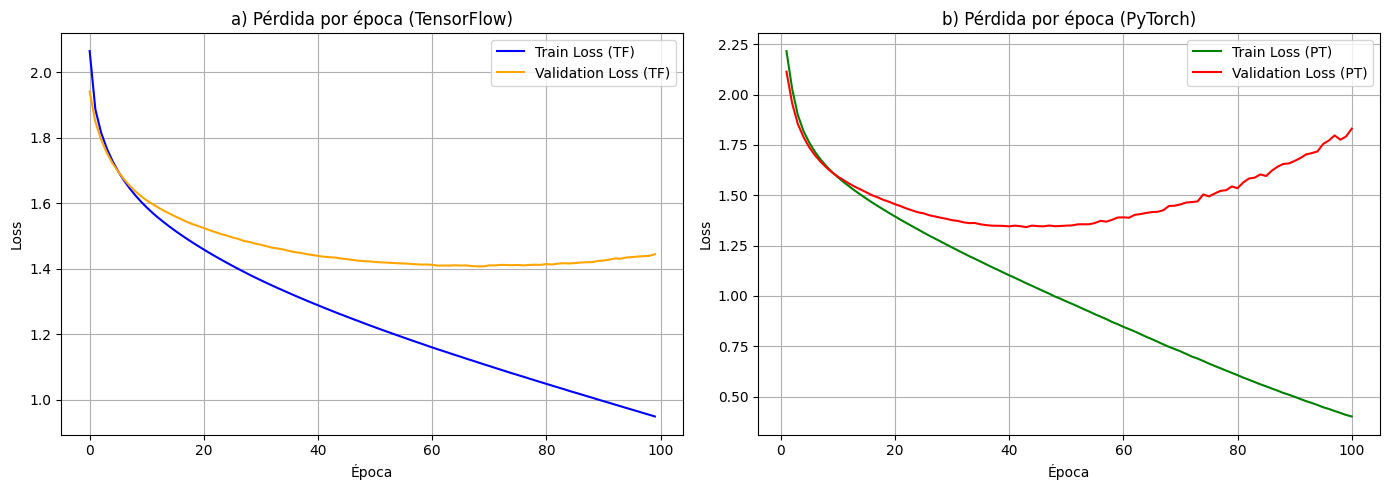

In [63]:
#gráficos de pérdida

loss = historial.history['loss']
val_loss = historial.history['val_loss']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# ------------------- Panel A: TensorFlow -------------------
ax1.plot(loss, label='Train Loss (TF)', color='blue')
ax1.plot(val_loss, label='Validation Loss (TF)', color='orange')
ax1.set_title('a) Pérdida por época (TensorFlow)', loc='center')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.grid(True)
ax1.legend()

# ------------------- Panel B: PyTorch -------------------
ax2.plot(range(1, num_epochs + 1), train_losses, label='Train Loss (PT)', color='green')
ax2.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss (PT)', color='red')
ax2.set_title('b) Pérdida por época (PyTorch)', loc='center')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

El número de épocas es importante porque un valor elevado ellas puede llevar a sobreajuste y un valor abajo a subajuste. Es decir, el número de épocas afecta la precisión y capacidad del modelo.

En el caso de Tensorflow, al llegar a 50 épocas la precisión seguía incrementando y la pérdida disminuyendo tanto en los datos de entrenamiento como en la validación. Aunque ya no se observa una ganancia sustancial.

Si se comparan ambos frameworks, vemos que los dos tienen una precision similar tanto en el dataset de prueba (Tensorflow 50,95% y Pythorch 51,05%) como en el de validación (Tensorflow 51,07% y Pytorch 50,86%).

Si observamos el comportamiento de la función de pérdida, en el caso de Pytorch la pérdida en el conjunto de validación alcanza su mínimo alrededor de la época 50 mientras que en el conjubnto de entrenamiento la pérdida sigue disminuyendo. Esto indica que a partir de la época 50 el modeloempieza a sobreajustarse.
En el caso de Tensorflow, la función de pérdida en el set de validación alcanza el mínimo cerca de 65 épocas. En el set de entrenamiento, sin embargo, el error sigue disminuyendo, lo que lleva nuevamente a sobreajuste a partir de 65 épocas. En términos del accuracy los frameworks tienen un comportamiento similar. no obstante, el framework Pytorch alcanza el mínimo en la funcion de pérdida en el conjunto de validación con un menor número de épocas, lo que en principio, es una mejor opción que Tensorflow.

## Consideraciones Adicionales

1. ¿Qué framework ofrece una mayor flexibilidad?

Pytorch permite estructura de código tipo python, a diferencia de tensorflow, que tiene una estructura más delimitada. Es decir, en Pytorch es posible peronalizar el modelo con estructuras de programación como en python, mientras que en tensorflow hay una selección de opciones predeterminada y es más dificil de modificar. En este sentido, el framework pytorch puede resultar más flexible.

2. ¿Cuál framework facilita más la depuración en caso de que haya errores en la definición del modelo?

Dada la mayor flexibilidad en su estructura y a que se puede ejecutar como en el entorno de python, Pytorch es más flexible para identificar, corregir y depurar errores en la definición del modelo. En Tensorflow, dada la estructura por ejemplo, de model.fit(), cuando ocurre algún error, estas fallas se encuentran dentro de las operaciones de model.fit(), por lo que identificarlas y corregirlas puede resultar más complicado.

3. Considerando que se ha utilizado el mismo set que en la practica anterior, ¿qué modelo ha tenido mejore resultados, SVM o la red feedforward? ¿por qué?

En el modelo SVM, la capacidad del modelo para predecir las imágenes fue baja en mi caso tanto para el kernel lineal (31%) como para el gaussiano (44,44%). No obstante, en dicho modelo la precisión se vió afectada por el parámetro C igual a 1. Es decir, predecía como si se tratara del modelo de margen máximo.

Bajo la red feedforward la precisión es mayor debido a que la red va aprendiendo hacia adelante al ajustar los ponderadores en cada pasada (epoca). Además bajo este método, el algoritmo aprende patrones, mientras que en SVM solo se trata de encontrar el hiperplano que mejor separa las clases.

4. ¿Qué ocurre si usamos la función de loss CrossEntropyLoss en torch y la última capa de la red tiene una activación softmax o log_softmax?

Se estarían aplicando dos veces la transformación logaritmica a los datos ya que bajo torch, CrossEntropyLoss ya tiene la activación log_softmax por defecto. Esto llevaría a estimar probabilidades de salida incorrectas en el modelo.

##Conclusiones

Los modelos de red feedforward tienen mayor precision que la SVM debido a que los primeros aprenden patrones y corrigen a medida que se van ejecutando. Esto que hace que los modelos de red feedforward tengan una mayor capacidad de predicción. Los modelos SVM, por otro lado, únicamente separan los datos mediante el ajuste del hiperplano separador que maximiza la distancia entre las clases, tomando como base a los vectores soporte.

Entre los frameworks Tensorflow y PyTorch, el rendimiento de ambos es similar, aunque PyTorch brinda un entorno de mayor flexibilidad y control para modificar los parametros y depurar errores en el modelo. En ambos casos, es importante realizar una búsqueda grid para la optimización de los hiperparámetros de "tasa de aprendizaje" y número de epocas ("epochs"). Esto con la finalidad de seleccionar el mejor modelo y de optimizar los recursos computacionales.